In [ ]:
from Bio import AlignIO 
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import math


format_type = 'phylip-relaxed'
phy_file = '/home/tommaso_cappelli_05/bzrs/ecoli_samples/core_alignment.phy'



alignment = AlignIO.read(phy_file, format_type)


num_bacteria = len(alignment)
n_bases = len(alignment[0])
print(num_bacteria)
print(n_bases)



92
2593095


In [8]:
#FIRST: comparing the genomics of 2 different E_coli Samples
n1 = 0
n2 = 0
while n1 == n2 or n1<1 or n1>92 or n2<0 or n2>92:
    n1 = int(input('Write the number of the first sample of E.Coli (1 to 92):'))
    n2 = int(input('Write the number of the first sample of E.Coli (1 to 92):'))

print(f'We are comparing the bacteria number {n1} and {n2}')
genome1 = alignment[n1-1]
genome2 = alignment[n2-2]  
Lr = 1000

n_intervals = int(n_bases / Lr) + 1
print(n_intervals)

SNP_counter = np.zeros(n_intervals, dtype = float) #every point will consider 1000 bases each
##every point will be 1000*(poistion+1) + 0-999


for ii in range(0, n_intervals): #consider singularly every point of the SNP counter
    for j in range(Lr): #for every Lr-length sequence, you must check the number of discrepancy points
        
        if ii * Lr + j >= n_bases:
            break
        if genome1[ii*Lr + j] != genome2[ii*Lr + j]: #different sequence, you need to increase
            SNP_counter[ii] += 1
        

print(SNP_counter) #the length of SNP counter is exactly n_intervals, so to create a plot I will have to build
#a vector like 1kb, 2kb and so on. Keeping the kb as the measuring unit, we can have range(1, n_intervals+1),
#and just define the whole thing as 'number of kbases where it's located the interval)

We are comparing the bacteria number 73 and 22
2594
[11. 15. 23. ...  8.  9.  0.]


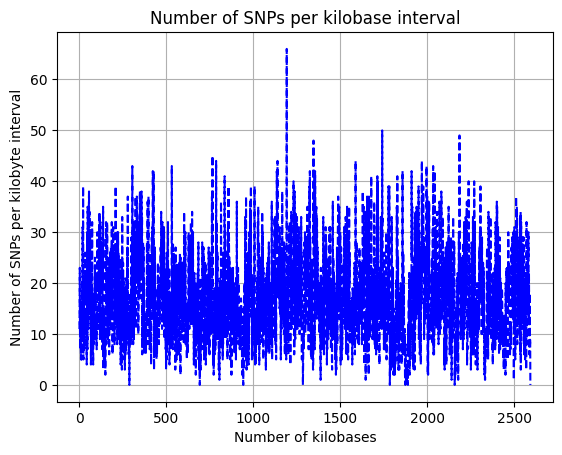

In [ ]:
#FIRST GRAPHIC: SNPs per interval
plt.figure(1)
plt.plot(range(1, n_intervals+1), SNP_counter, color = 'blue', linestyle = '--', marker = '')
plt.title('Number of SNPs per kilobase interval')
plt.xlabel('Number of kilobases')
plt.ylabel('Number of SNPs per kilobyte interval')
plt.grid(visible = 'True')
plt.legend
plt.show()

In [ ]:
#REQUEST N2: COMPARISON OF THE AMOUNT OF INTERVALS WITH A CERTAIN AMOUNT OF SNPs with the Poisson function
#now I have to count the number of intervals where I have the same amount of SNPs. Realistically, having kb intervals,
#I can't have more than 1000. Otherwise, I can just round that up to 500 or 300, but let's keep it 1000 = Lr

max_SNPs = int(max(SNP_counter)) #max SNPs that I can get for one single kb string

possible_SNPs = range(0, max_SNPs + 1) 

same_SNP_counter = np.zeros(max_SNPs + 1, dtype = float) #setting up the counter for the number of strings

for ii in range(0, n_intervals): #I have to check every interval
    
    for j in range(0, max_SNPs + 1): #with every number between 1 and 1000 until I found a match
        if SNP_counter[ii] == j: #SNP counter has to be the exact same as the number between 0 and 1000
            same_SNP_counter[j] += 1 #we get  a+1 interval in the position with that number of SNPs
            break #I stop the cycle in j


avg_SNPs = np.average(possible_SNPs, axis = 0, weights=same_SNP_counter)
print(avg_SNPs)

poisson_distribution = []
for i in possible_SNPs:
    poisson_distribution.append(n_intervals * pow(avg_SNPs,i) * math.exp(-avg_SNPs) / math.factorial(i) ) 


#


17.098689282960677


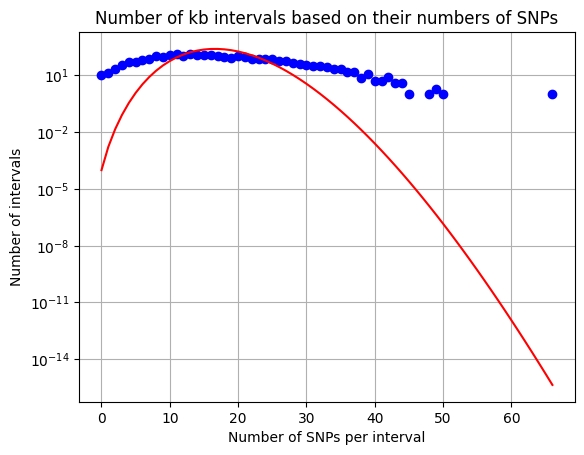

In [11]:
#GRAPHIC NUMBER 2 AND RESULTS
plt.figure(2)
plt.semilogy(possible_SNPs, same_SNP_counter, 'o', color = 'blue')
plt.semilogy(possible_SNPs, poisson_distribution, color = 'red')
plt.title('Number of kb intervals based on their numbers of SNPs')
plt.xlabel('Number of SNPs per interval')
plt.ylabel('Number of intervals')
plt.grid(visible = 'True')
plt.legend
plt.show() 
#On its own, the Poisson distribution, even if normalized, isn't precise enough to give an accurate estimate. This
#is due to the fact that ricombination itself drastically rises the number of SNP-dense factors, and therefore 
#the weighted average of the number of SNPs for each kilobases, and therefore the lambda factor of the Poisson distrbution. 
#The growth of Lambda makes the first values of the poisson distribution drop incredibly, and the distribution tends to 0 even quicker.
#That's the reason why a mixture model is used and tested empirically to approximate the approximative curve that follows the dots
#with parameters such as lambda and alfa that are estimated